<center><h1>An Introduction to OpenFace for Head and Face Tracking </h1>


<h3> James Trujillo ( j.p.trujillo@uva.nl)<br>
    Anna Palmann (a.palmann@uva.nl)<br>
    01-07-2026 </h3>
    
<h3> Info documents </h3>
This Python coding module demonstrates how to use OpenFace, an open-source program that provides face and head tracking of images or videos. In the first part of this module, we'll go over basic installation, simple commands to run the tracking, and get a first look at the output data.
<br>
In the second part, we'll go into some basic analyses of face and head data.<br>

* OpenFace: https://github.com/TadasBaltrusaitis/OpenFace
* Citation: OpenFace 2.0: Facial Behavior Analysis Toolkit Tadas Baltrušaitis, Amir Zadeh, Yao Chong Lim, and Louis-Philippe Morency, IEEE International Conference on Automatic Face and Gesture Recognition, 2018

* Visual Studio download (VS required to run OpenFace via command line): https://visualstudio.microsoft.com/thank-you-downloading-visual-studio/?sku=Community&rel=17

* A detailed tutorial for using ExploFace: https://github.com/emrecdem/exploface/blob/master/TUTORIALS/tutorial1.ipynb 

* location code: 
[ TO BE ADDED ]

<h3>Notes on Running this notebook</h3>
Exploface has many dependencies that do not work on new versions of Python. We therefore recommend that you use an older version, and follow the package versions listed in requirements.txt. This notebook was created in <b>Python 3.9</b>.<br>
Packages to download:
  
-<i> pandas </i>

-<i> exploface </i>

-<i> scipy</i>

-<i> pympi-ling</i>

-<i> praat-parselmouth</i>

-<i> numpy</i>

-<i> seaborn</i>


(note that you can also download all required packages using <i>pip install -r requirements.txt</i>

Citation: 
Trujillo, J.P. & Palmann, A. (01-07-2026). <i>  An Introduction to OpenFace for Head and Face Tracking</i> \[day you visited the site]. https://envisionbox.org/embedded_OpenFace_module



<h3> Installing OpenFace </h3>

* Download the latest binaries from https://github.com/TadasBaltrusaitis/OpenFace/wiki/Windows-Installation 

* Unzip the folder into a directory of your choosing -- we recommend unzipping into the FaceTracking_OpenFace directory
    
* You will also need to download the models that OpenFace uses for feature detection.
  This can be done using powershell (search in your taskbar for powershell, right-click --> run as administrator)

* Navigate to the OpenFace directory (the one that you unzipped. it's probably called something like <i>OpenFace_2.2.0_*</i>)
* Run:  <i> powershell -ExecutionPolicy Bypass -File .\download_models.ps1</i>

 You won't see anything directly under your command after running it, but the top of the window should show that your system is downloading it
  <img src="./images/powershell.png"> </center>

<h3> Running OpenFace </h3>

* <b> To run offline</b>, using a GUI, you can navigate to the main folder and run double-click OpenFaceDemo.exe

* <b> To run via command line</b>, you need a cmd prompt open to the OpenFace directory.
For example, I have cmd line running in <i>D:\data\MoCap\OpenFace_2.2.0_win_x64\OpenFace_2.2.0_win_x64</i>


<i>FeatureExtraction.exe</i> is the main function for processing single faces,
<i>FaceLandmarkVidMulti.exe</i> is used when there are multiple faces

For example, to run OF on the sample video provided, we can type the following in cmd:
<i>D:\
FeatureExtraction.exe -f "./samples/2015-10-15-15-14.avi"</i>
OpenFace will update you on the progress
<img src="./images/OF_running.png"></center>

<br> By default, you get a folder in the OpenFace directory called <i>processed</i> where all the output is stored. However, this means all output .csv files, video files, etc are all thrown in one folder. If you don't want this, you can specify an output directory by adding the following to the FeatureExtraction command:
<i>-out_dir "output_path"</i> 
<br>
<b> Timing: </b>
Depending on your machine, OF takes approximately the duration of your video +20% 
<br><br>
However, you probably want to process multiple files in a batch. For this, we can use the python code below. It uses the same commands shown here, but runs them via Python. We loop through each video in the <i>videos_to_process</i> folder, create a new output folder for the results in <i>OF_output</i>, and then process the video.

<center><h1> Part 1: Getting started with OpenFace </h1>

In [2]:
from pathlib import Path
import subprocess
import os

# Main directories
VIDEO_DIR = "./videos_to_process/"
OUTPUT_DIR =  "./OF_output/"

In [ ]:
# find the OpenFace directory (e.g. OpenFace_2.2.0_win_x64)
openface_dir = "./OpenFace_2.2.0_win_x64/"

# path to FeatureExtraction.exe
feature_exe = openface_dir + "FeatureExtraction.exe"

# video extensions to process
VIDEO_EXTENSIONS = {"mp4", "avi", "mov", "mkv", "wmv", "mpeg"}

failed = []

for filename in os.listdir(VIDEO_DIR):
    video_path = os.path.join(VIDEO_DIR, filename)
    
    if video_path.split('.')[-1].lower() not in VIDEO_EXTENSIONS:
        continue
    # make the output folder
    output_path = OUTPUT_DIR + filename.split('.')[0]

    # skip if the video has already been processed
    if os.path.isdir(output_path):
        print(f"Skipping {filename} (already processed)")
        continue
        
    os.mkdir(output_path)

    print(f"\nProcessing {filename}...")

    # this part actually runs the .exe file for us, assembling the complete call that
    # includes the output path and video name
    try: 
        subprocess.run(
            [
                str(feature_exe),
                "-f",
                str(video_path),
                "-out_dir",
                str(output_path),
            ],
            capture_output=True,
            text=True,
        )

    except subprocess.CalledProcessError as e:
        print(f"Failed ({e.returncode})")
        failed.append(filename)

    except Exception as e:
        print(f"Unexpected error: {e}")
        failed.append(filename)

print("\nFinished processing.")

if failed:
    print("\nThe following files failed:")
    for name in failed:
        print(f"  - {name}")
else:
    print("All videos processed successfully.")

<h3> OpenFace Output </h3>
OpenFace provides several types of output, including a video visualizing the tracking, as well as a .csv containing coordinate data, rotation data, and action units.

First, let's take a look at the output video. How does it perform? You should be thinking about the types of questions you want to ask using your data, and take a critical look at whether the tracking is sensitive and accurate enough to serve your purpose. Remember that (some) jitter can be removed with smoothing!

Now, let's take a look at the numerical data, and what was actually tracked. <br>
<b> Action Units</b><br>
OpenFace recognizes a subset of all possible action units. These include:
* 1: inner brow raiser
* 2: outer brow raiser
* 4: brow lowerer
* 5: upper lid raiser
* 6: cheek raiser
* 7: lid tightener
* 9: nose wrinkler 
* 10: upper lip raiser
* 12: lip corner puller (smile)
* 14: dimpler
* 15: lip corner depressor (sad)
* 17: chin raiser
* 20: lip stretcher
* 23: lip tightener
* 25: lips part
* 26: jaw drop
* 28: lip suck – only presence, not intensity
* 45: blink
<img src="./images/AUs.jpg"></center>
<br> 
OpenFace provides two sets of columns for these AUs. 

* Presence: given in the AU*_c columns, this just indicates whethere the AU is present in a given frame
* Intensity: given in the AU*_r columns, this provides an indication of the intensity of the action unit.
NOTE: These two values are estimated by two different models, which means sometimes there is no AU detected, but intensity != 0
<br>
<b> Facial Landmark Coordinates </b><br>
We also have facial landmark locations. For each of these 68 landmarks we get at least 4 values: tracking confidence (0-1), tracking success (binary - was anything tracked?), as well as an x and y location, given in pixels.
<img src="./images/landmark_scheme_68.png"></center>

<br>
<b>Head Pose </b><br>
We also get the relative pose of the head. This is provided in <i>Translation</i>, which gives the location of the head with respect to the camera centre, given in millimiters. We also get <i>Rotation</i> which proves the rotation of the head in radians around the 3 axes<br>
* <b>Pitch</b> is the head rotating "up and down" (nodding)
* <b>Roll</b> is the head tilting side to side (ear to shoulder)
* <b>Yaw</b> is the head turning left and right (looking over the shoulder) 
<img src="./images/head.png"></center>


<b>Eye Gaze</b><br>
OpenPose also provides an estimation of the looking direction of the the eyes. This is given in gaze direction, as well as eye landmarks (see picture below, similar to the facial landmark x,y coordinates).<br>
You get both vector coordinates for the eyes (gaze_0_x/y) as well as angular direction (gaze_angle_x/y). <br>
Good to know: <br>
* all values are given in world coordinates (not relative to head)
* angular values will be close to 0 if person is looking straight ahead
* angle_x = left to right; angle_y = up and down

<img src="./images/eye_lmk_markup.png"></center>


Rather than write our own scripts to summarize different aspects of the data, we can make use of ExploFace to do much of this
(remember to install exploface before running! <i>pip install exploface</i>

<h3> Importing OpenFace into ELAN Using ExploFace </h3>

This first command just gets the .csv file and loads them into a dataframe. This can be a useful starting point if you want to run further analyses.

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import exploface
import glob
import numpy as np
import seaborn as sns

for out_path in os.listdir(OUTPUT_DIR):
    output_filename = glob.glob(OUTPUT_DIR + out_path + "/*.csv")[0]
    # we'll stop here, just to get an example file
    break
    

openface_features = exploface.get_feature_time_series(output_filename)


If you want a full list of what the different columns correspond to, you can check the OpenFace 2.0 Github page: https://github.com/TadasBaltrusaitis/OpenFace/wiki/Output-Format 

let's have a look at the dataframe <br><br>

Note that this notebook is designed for a dataframe from the BALANCE corpus and the parameters and comments make sense for that. <br>
If you want to use a dataframe from the PARSEL corpus instead, some parameters and thresholds need to be adapted

In [7]:
openface_features.head(5)

,frame,face_id,timestamp,confidence,success,gaze_0_x,gaze_0_y,gaze_0_z,gaze_1_x,gaze_1_y,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
0,1,0,0.000,0.98,1,-0.033749,0.408510,-0.912130,-0.169951,0.401919,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,0,0.033,0.98,1,-0.032349,0.414795,-0.909340,-0.170565,0.408587,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,0,0.067,0.98,1,-0.032115,0.413529,-0.909925,-0.170881,0.407479,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4,0,0.100,0.98,1,-0.031631,0.415054,-0.909247,-0.170712,0.409613,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5,0,0.133,0.98,1,-0.029914,0.416529,-0.908630,-0.168198,0.410160,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Exploface can do a bit more than this though. A useful feature here is to get some summary statistics of what's happening in your video.

In [8]:
stats_df = exploface.get_statistics(output_filename)
stats_df

,nr_detections,average_length_detection,std_average_length_detection
AU01,6,0.551667,0.545616
AU02,5,0.172000,0.057184
AU04,3,5.700000,5.784280
AU05,7,2.002857,1.744560
AU06,8,0.592500,0.613672
AU07,3,5.700000,5.784280
AU10,9,1.726667,1.776739
AU12,13,0.283846,0.190374
AU14,3,5.700000,5.784280
AU17,11,0.322727,0.272694


Here we see the Action Unit detections, along with how many there were of each one, and their durations.
<br>
One of the nicer features here is that we can also convert these .csv data into a .eaf file for use in ELAN. We could then import these annotations into ELAN for further checking/cleaning, or for further analysis in ELAN itself.

In [ ]:
feature_detections = exploface.get_detections(
                                            openface_features,
                                            skip_seconds_at_end=0,
                                            intensity_threshold=0.8,
                                            time_threshold=0.1,
                                            smooth_time_threshold = 0.1,
                                            uncertainty_threshold=0.9
                                             )

video_file = glob.glob(VIDEO_DIR +out_path + ".mp4")[0]

dataframe_timestamp = exploface.write_elan_file(feature_detections,
                                                  video_path=video_file,
                                                  output_path="sample_vid.eaf",
                        )

<h3>Potential Applications</h3>

* Speech-(head)gesture coupling
* Automatic gaze detection (who's looking at whom when?)
* (...)

<h3> Notes on Reliability </h3>

OpenFace provides some very useful output, and tracking quality seems to be good. However, note that you shouldn't take the output as true until you check it. <br>
In particular, many studies use the AU output without any (or very little) quality control. However, a corpus project looking at facial signals in conversation (see Nota et al., 2021; https://doi.org/10.3390/brainsci11081017 ) attempted to use OpenFace, but went with manual coding for most features instead, as AU detection is far from 100% accurate. It can be an interesting starting point to explore data, but the explicit detections absolutely <i>must</i> be checked and cleaned. <br> For a more in-depth discussion of these issues, and some tips on how to tune Exploface thresholds to get more reliable output, see Nota, Trujillo & Holler, 2026: https://osf.io/dtz5p/ 

<center><h1> Part 2: Data Analysis </h1>

This coding module gives an introduction to using the output of OpenFace. We'll discuss cleaning the data, extracting relevant features, merging kinematic data with annotation data, and using Parselmouth (a python interface for working with Praat) to extract prosodic features from the audio stream in order to perform a simple analysis of kinematic-prosodic alignment. We will further do some analyses of head pose and eye gaze. 
<br><br>

<h3> Kinematic-prosodic alignment </h3>

First, let's load in the data and apply some smoothing. We use a Savitzky-Golay-Filter for that.

In [4]:
from scipy import signal

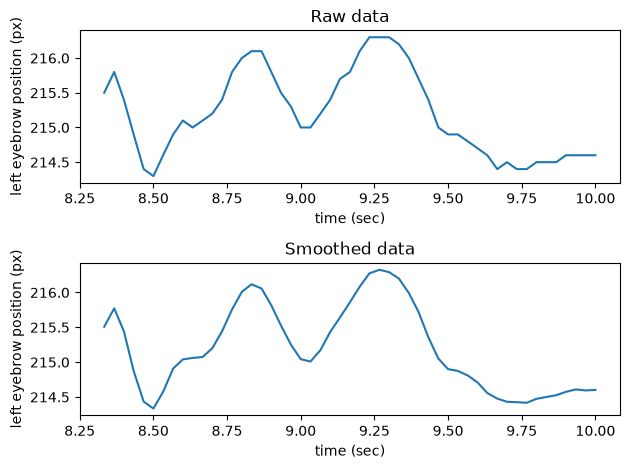

In [20]:
# let's compare raw and smoothed position
plt.subplot(2,1,1)
plt.plot(openface_features.loc[250:300,"timestamp"],openface_features.loc[250:300,"y_24"])
plt.xlabel("time (sec)")
plt.ylabel("left eyebrow position (px)")
plt.title("Raw data")
plt.subplot(2,1,2)
plt.plot(openface_features.loc[250:300,"timestamp"],signal.savgol_filter(openface_features.loc[250:300,"y_24"],5,3))
plt.xlabel("time (sec)")
plt.ylabel("left eyebrow position (px)")
plt.title("Smoothed data")
plt.tight_layout()
plt.show()

As we see above, the smoothing helps to iron our some of the jitter that is inherent to video based tracking, without affecting the main shape of the signal. <br>
Before we go on to any analysis, we need to get a time-series that is useful for us. In this case, we currently only have the position of the eyebrow landmarks in pixel space. This isn't always helpful, as movement of the head will also affect this position, and (at least for A/V coupling) we are mostly interested in kinematics, not position.<br>



In [5]:
import math
eyebrow_L = openface_features[["timestamp","x_24","y_24"]].rename({"x_24":'X',"y_24":"Y"},axis='columns')
eyebrow_R = openface_features[["timestamp","x_19","y_19"]].rename({"x_19":'X',"y_19":"Y"},axis='columns')
nose = openface_features[["timestamp","x_33","y_33"]].rename({"x_33":'X',"y_33":"Y"},axis='columns')

def nosecorrected_velocity(ts, nose,FPS):
    '''
    We want to calculate velocity, but not of the eyebrow out of context of the face -
    rather we want to get the relative movement. To do so, we calculate it as a funcion of
    where the eyebrow is in relation to a fixed point, such as the nose
    '''
    # first, get the relative position
    # we'll use list comprehension to make a new timeseries consisting of x,y pairs 
    rel_ts = [ [row['X']-nose.loc[idx,'X'], row['Y']-nose.loc[idx,'Y']] for idx,row in ts.iterrows()]
    
    
    IDX = 0
    vel = []
    for coords in rel_ts[1:]:
        Prev_coords = rel_ts[IDX]
        # first calculate displacement
        DISPLACE = math.hypot(float(coords[0]) - float(Prev_coords[0]), float(coords[1]) - float(Prev_coords[1]))
        # remove any change in head position
        
        # then calculate velocity
        vel.append(DISPLACE * FPS)
        IDX += 1
    vel = list(vel)
    # now smooth the velocity time-series
    vel_sm = signal.savgol_filter(vel, 5,3)
    
    return vel_sm

eyebrow_L_sm = nosecorrected_velocity(eyebrow_L, nose, 25)
eyebrow_R_sm = nosecorrected_velocity(eyebrow_R, nose, 25)

Now that we have some time series to work with, let's get some annotations and use these to calculate the kinematic-prosodic coupling. For our prosody calculations, we'll be using a package called Parselmouth. Parselmouth provides a Python interface for PRAAT and allows us to directly calculate (and manipulae) many features of a speech signal.<br>
First, let's load in the annotations, get the speech signal, and extract the pitch values. <br>
For the sake of this tutorial, we'll just grab the first annotation file that corresponds to our current file name. To fully process a batch of files, you'd need to wrap this into a loop. <br>
<b>Note:</b> the annotation file provided here was generated using the silence detector in ELAN 6.8. Just a quick and dirty approximation of utterance timestamps. For a proper analysis, you'd need to generate these annotations for all of your files, and you need to decide what types of annotations you are interested in: single words, clauses, utterances? That's beyond the scope of this module. For now, let's just see how we can calculate the temporal correspondence between a facial feature (in this case, eyebrow movement) and speech acoustics, within some set annotation time-windows.


In [27]:
# pip install pympi-ling
import pympi
import parselmouth
from parselmouth.praat import call

annot_file = pd.read_csv("./annotations/" + out_path + ".txt", sep="\t")

timestamps = eyebrow_L["timestamp"]

annot_file.head()
# first we load in the audio file.
sound = parselmouth.Sound(glob.glob("./audio/" + out_path[0:37] + "*")[0])

for annot_idx,row in annot_file.iterrows():
    # now we get the audio fragment corresponding to this annotation
    annot_start = row["Begin Time - msec"]/1000
    annot_end = row["End Time - msec"]/1000
    sound_frag = sound.extract_part(from_time=annot_start,to_time=annot_end)
    
    # we'll also get the motion tracking timestamps for this fragment
    timestamps_current = timestamps[int(annot_start*25):int(annot_end*25)]
    timestamps_current = timestamps_current.reset_index()
    
    # now extract pitch values
    pitch = call(sound_frag, "To Pitch", 0.01, 75, 300)
    pitch_times = pitch.xs()
    pitch_time_s = list(pitch_times)
    pitch_time_s = [val + (annot_start) for val in pitch_time_s]
    pitch_values = pitch.selected_array['frequency']
    pitch_values = list(pitch_values)
    
    # now we want to get the maximum value and its time point
    max_pitch = max(pitch_values)
    pitch_index = pitch_values.index(max_pitch)
    
    # we should also get the max eyebrow movement and its index
    # first we need to take a subset of the data, which corresponds to our annotation
    # Since we know the data start at 0, we can convert the annotation times (currently in seconds)
    # into frame numbers
    annot_start_index = int(annot_start*25)
    annot_end_index = int(annot_end*25)
    
    eyebrow_L_this_annot = list(eyebrow_L_sm[annot_start_index:annot_end_index])
    eyebrow_R_this_annot = list(eyebrow_R_sm[annot_start_index:annot_end_index])
    # now we get the max value and index
    max_brow_L = max(eyebrow_L_this_annot)
    max_brow_R = max(eyebrow_R_this_annot)
    max_brow_L_index = eyebrow_L_this_annot.index(max_brow_L)
    max_brow_R_index = eyebrow_R_this_annot.index(max_brow_R)
    
    # now let's update our annotation dataframe to have all of these values
    annot_file.loc[annot_idx,"pitch_peak_val"] = max_pitch
    annot_file.loc[annot_idx,"pitch_peak_time"] = pitch_time_s[pitch_index]
    annot_file.loc[annot_idx,"brow_L_val"] = max_brow_L
    annot_file.loc[annot_idx,"brow_R_val"] = max_brow_R
    annot_file.loc[annot_idx,"brow_L_time"] = timestamps_current.loc[max_brow_L_index,"timestamp"]
    annot_file.loc[annot_idx,"brow_R_time"] = timestamps_current.loc[max_brow_R_index,"timestamp"]



To get a correspondence between the two signals, we need to calculate the offset between them. The code below calculates the time difference between the peak eyebrow movement and the peak pitch. The hypothesis then, is that the peaks of the respective signals should align with one another in an utterance. 

In [28]:
annot_file["pitch_browL_diff"] = annot_file["brow_L_time"] - annot_file["pitch_peak_time"]
annot_file["pitch_browR_diff"] = annot_file["brow_R_time"] - annot_file["pitch_peak_time"]

Now we can draw the distributions and see if there is any correspondence/alignment. Note that we could also save this dataframe as a new .csv file, so we don't have to repeat these steps, or in case you wish to continue analyses in R, but for now let's see what we can do in Python.<br>
For plotting, we'll use the seaborn package. 

In [41]:
annot_file.head(10)

,Begin Time - msec,End Time - msec,Channel1,pitch_peak_val,pitch_peak_time,brow_L_val,brow_R_val,brow_L_time,brow_R_time,pitch_browL_diff,pitch_browR_diff
0,400,680,x,0.000000,0.420000,5.121947,5.134890,0.500,0.433,0.080000,0.013000
1,1080,6260,x,256.213736,2.590000,10.251846,11.569326,2.867,3.033,0.277000,0.443000
2,7060,10060,x,285.273748,7.370000,10.994687,11.453490,7.867,7.867,0.497000,0.497000
3,10420,13920,x,205.179941,11.700000,9.233263,10.803857,9.067,10.733,-2.633000,-0.967000
4,14260,17414,x,195.407725,15.721995,11.842846,13.228716,13.633,13.367,-2.088995,-2.354995


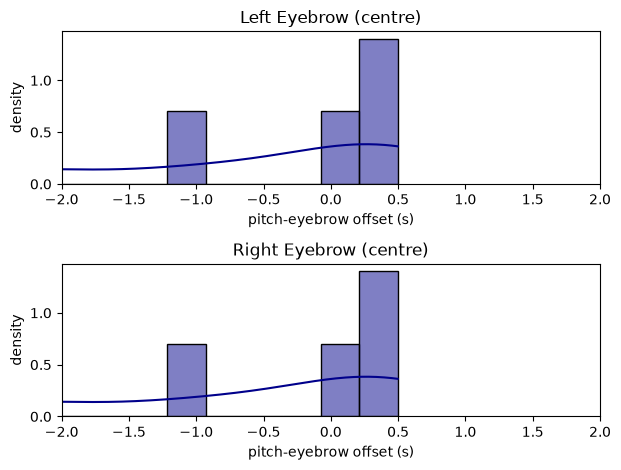

Mean offset of left eyebrow: -0.7735990929705215 seconds
Mean offset of right eyebrow: -0.47379909297052114 seconds


In [48]:
import seaborn as sns
import numpy as np

plt.subplot(2, 1, 1)
sns.histplot(
    annot_file['pitch_browR_diff'],
    bins=10,            
    stat='density',
    color='darkblue',
    edgecolor='black',
    kde=True,
    kde_kws={ 'bw_adjust': 0.7} 
)
plt.xlabel("pitch-eyebrow offset (s)")
plt.ylabel("density")
plt.title("Left Eyebrow (centre)")
plt.tight_layout()
plt.xlim(-2, 2)

plt.subplot(2, 1, 2)
sns.histplot(
    annot_file['pitch_browR_diff'],
    bins=10,            
    stat='density',
    color='darkblue',
    edgecolor='black',
    kde=True,
    kde_kws={ 'bw_adjust': 0.7} 
)
plt.xlabel("pitch-eyebrow offset (s)")
plt.ylabel("density")
plt.title("Right Eyebrow (centre)")
plt.tight_layout()
plt.xlim(-2, 2)

plt.show()

print("Mean offset of left eyebrow: " + str(np.mean(annot_file["pitch_browL_diff"])) + " seconds")
print("Mean offset of right eyebrow: " + str(np.mean(annot_file["pitch_browR_diff"])) + " seconds")


We can see that for both eyebrows, the kinematic peak occurs approximately 500 ms before the pitch peak. However, the distributions also suggest that the data is rather skewed by some early eyebrow peaks. Of course, this is based on one rather short clip, so to get a proper idea, you'd want to analyze this over more speakers, and many more utterances.

<h3> Head Pose Analysis </h3>

Let's have a look at how the head moves. As mentioned above, we have data for the <b>translation</b> (the location of the head with respect to the camera centre) and the <b>rotation</b> on three axes. Consider that the head moves by rotating in several directions around a joint. We can identify three axes, x [horizontal], y [depth], z [vertical]. There are then three complementary rotations that we can track. One is the head raise position, called head <b>pitch</b>, important for tracking head nodding, which is a rotation around the x-axis. Another is called <b>yaw</b>, which is important for tracking head shaking, which is a rotation around the z-axis. Finally there is head tilt, called <b>roll</b>, which is a rotation around the y axis. Each rotation is expressed in angles (degrees in this case). How do you determine which direction is a negative versus positive direction? You use the right hand rule: Grab an axis, such your hand curl in the direction of the rotation, and then see what direction your thumb is directed at on the axis. Is that the positive or negative direction on that axis (remember, on the vertical z axis up is positive, on the horizontal x axis rightward is positive, and in the depth y dimension forward is positive).

Let's have a look at rotation. We will load in the data and apply some smoothing to the relevant columns: Rx, Ry, Rz with the following formula for rotation: <b>R = Rx * Ry * Rz</b>

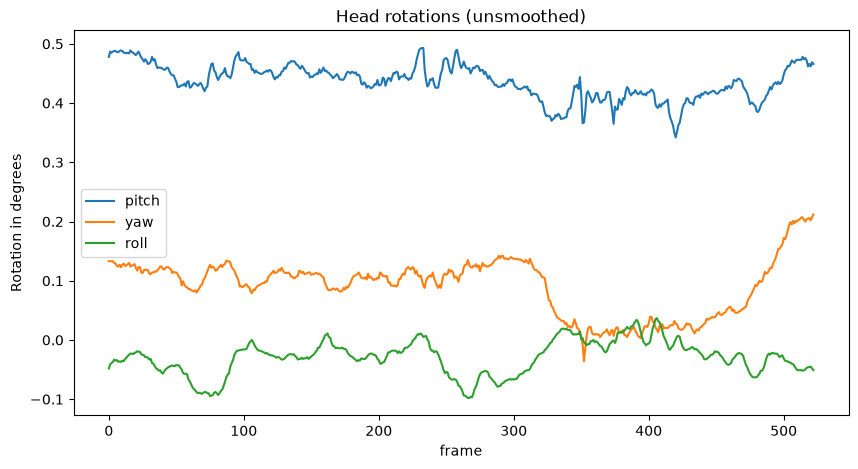

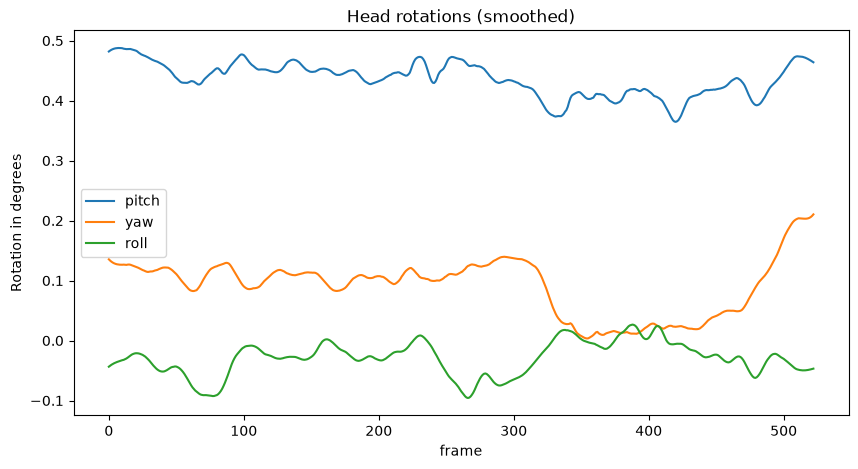

In [21]:
# define variables
xrot = openface_features['pose_Rx']
yrot = openface_features['pose_Ry']
zrot = openface_features['pose_Rz']

# plot it
plt.figure(figsize=(10,5))
plt.plot(xrot, label = 'pitch')
plt.plot(yrot, label = 'yaw')
plt.plot(zrot, label = 'roll')
plt.xlabel('frame')
plt.ylabel('Rotation in degrees')
plt.title('Head rotations (unsmoothed)')
plt.legend()
plt.show()

# smooth the signal
xrot_smooth = signal.savgol_filter(xrot, 21, 3) # you can change the span and order here, and you see that the smoothness of the curve will change accordingly
yrot_smooth = signal.savgol_filter(yrot, 21, 3)
zrot_smooth = signal.savgol_filter(zrot, 21, 3)

# plot it
plt.figure(figsize=(10,5))
plt.plot(xrot_smooth, label = 'pitch')
plt.plot(yrot_smooth, label = 'yaw')
plt.plot(zrot_smooth, label = 'roll')
plt.xlabel('frame')
plt.ylabel('Rotation in degrees')
plt.title('Head rotations (smoothed)')
plt.legend()
plt.show()

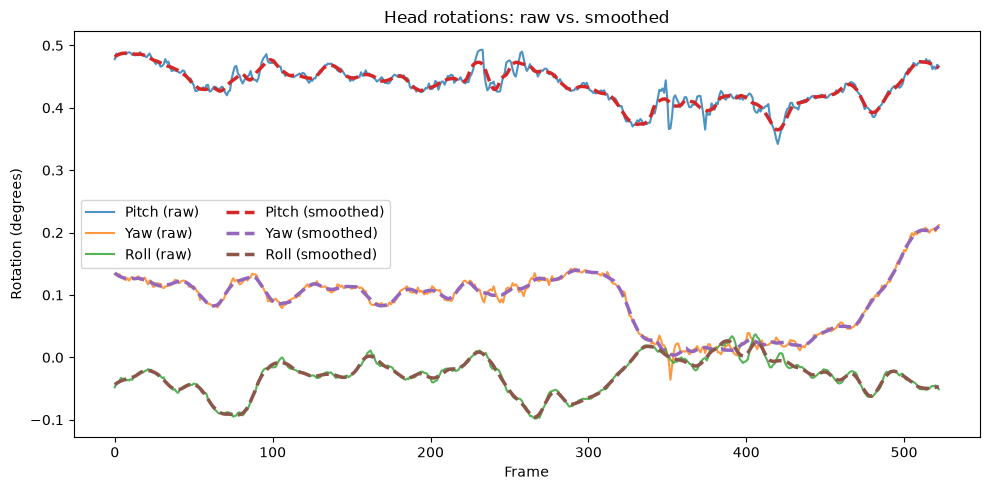

In [22]:
# we can also create one plot to compare thesmoothed and unsmoothed signals
plt.figure(figsize=(10, 5))

# Raw (solid)
plt.plot(xrot, '-', linewidth=1.5, alpha=0.8, label='Pitch (raw)')
plt.plot(yrot, '-', linewidth=1.5, alpha=0.8, label='Yaw (raw)')
plt.plot(zrot, '-', linewidth=1.5, alpha=0.8, label='Roll (raw)')

# Smoothed (dashed)
plt.plot(xrot_smooth, '--', linewidth=2.5, label='Pitch (smoothed)')
plt.plot(yrot_smooth, '--', linewidth=2.5, label='Yaw (smoothed)')
plt.plot(zrot_smooth, '--', linewidth=2.5, label='Roll (smoothed)')

plt.xlabel('Frame')
plt.ylabel('Rotation (degrees)')
plt.title('Head rotations: raw vs. smoothed')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

If you look carefully at the plot, you can see the dotted lines (the smoothed signal) smoother than the full lines (unsmoothed signal). However, sometimes it also smooths out some peaks and troughs, as in the yaw signal around frame 350. If we decrease the span when defining the filter, the smoothing will be less but it might also keep the information about peaks. You can play around with those parameters (e.g change from 21 to 11 and see how it changes the signal) and ultimately you want to retain information but smooth out jitter.

Now we can look into some behavior patterns that might be relevant for conversation, such as how many head shakes or nods, and how deep these are overall or maximally. Let's start with the number of peaks, and the prominences of the peaks (i.e. how the peak stands out relative to the surrounding of the signal). Troughs are peaks in the negative direction, so all the dips in the signal. In this example, we'll do that for pitch (Rx) but you can apply the same analysis also to yaw and roll.

In [23]:
import numpy as np
from scipy.signal import find_peaks
from scipy.signal import find_peaks, peak_prominences

# define function for getting peaks and troughs of head rotation
def get_peak_head_data(rot, threshpeak= 0.3, peakdist = 5, prominence=0.01): 
    # threspeak is the threshold for what counts as a peak, peakdist is the minimum distance between two adjacent peaks and prominence is how much the peak stands out
    """This function takes a rotation time series and returns the peaks and troughs."""
    peaks, _ = find_peaks(rot, height=threshpeak, distance=peakdist, prominence = prominence)  # Find peaks above the threshold
    troughs, _ = find_peaks(rot * -1, distance=peakdist, prominence = prominence)  # Find troughs by inverting the series, note that we omitted the height here but you can also add it again
    
    # initialize default values
    peak_prom = np.array([]) 
    trough_prom = np.array([]) 
    numpeaks = 0
    avgprom = 0
    maxprom = 0
    
    # only if peaks and toughs exist
    if len(peaks) > 0 and len(troughs) > 0:
        # get the prominences of the peaks and troughs
        peak_prom = peak_prominences(rot, peaks)[0]
        trough_prom = peak_prominences(rot * -1, troughs)[0]
        
        # Calculate summary statistics
        numpeaks = len(peaks) + len(troughs)
        if len(peak_prom) > 0 or len(trough_prom) > 0:
            avgprom = np.mean(np.concatenate([peak_prom, trough_prom])) if (len(peak_prom)+len(trough_prom)) > 0 else 0
            maxprom = np.max(np.concatenate([peak_prom, trough_prom])) if (len(peak_prom)+len(trough_prom)) > 0 else 0
    
    return peaks, peak_prom, troughs, trough_prom, numpeaks, avgprom, maxprom

In [24]:
# apply the function for pitch
xrot_smooth = np.nan_to_num(xrot_smooth) # replace missing values with 0

peaks, peak_prom, troughs, trough_prom, numpeaks, avgprom, maxprom = get_peak_head_data(xrot_smooth)

print("peaks:", peaks)
print("troughs:", troughs)


peaks: [ 98 137 230 254 348 397 465]
troughs: [ 67 124 194 241 331 375 420 480]


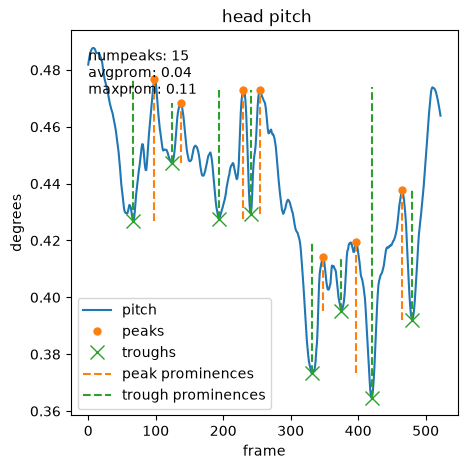

In [25]:
# now we can plot peaks and troughs

plt.figure(figsize=(5,5))
plt.plot(xrot_smooth, label='pitch')
plt.plot(peaks, xrot_smooth[peaks], ".", label='peaks', markersize=10)
plt.plot(troughs, xrot_smooth[troughs], "x", label='troughs', markersize=10)

# Plot prominences for peaks
for peak, prom in zip(peaks, peak_prom):     # note that zip is used to iterate over two lists at the same time
    plt.vlines(x=peak, ymin=xrot_smooth[peak] - prom, ymax=xrot_smooth[peak], color='C1', linestyle='--', label='peak prominences' if peak == peaks[0] else "")

# Plot prominences for troughs
for trough, prom in zip(troughs, trough_prom):
    plt.vlines(x=trough, ymin=xrot_smooth[trough], ymax=xrot_smooth[trough] + prom, color='C2', linestyle='--', label='trough prominences' if trough == troughs[0] else "")

# Plot the number of peaks and the average and max prominence 
plt.text(
    0, np.max(xrot_smooth),
    f"numpeaks: {numpeaks}\navgprom: {avgprom:.2f}\nmaxprom: {maxprom:.2f}",
    fontsize=10,
    va='top'
)
plt.xlabel('frame')
plt.ylabel('degrees')
plt.title(' head pitch')
plt.legend()
plt.show()

If the algorithm does not detect peaks or troughs but you are sure they are there from inspecting the graph, you want to tweak the parameters for height, distance, and prominence until it performs correctly.

<h3>Speed of Head Movements</h3>

Another aspect we can look at is speed of head movements. We can do that overall or spearately for the x,y,z dimensions.

In [26]:
def calcrotationspeed(openface_features, fps = 30):
    """This function calculates the speed of the head rotation"""
    
    dRx = np.diff(xrot, prepend=xrot[0])
    dRy = np.diff(yrot, prepend=yrot[0])
    dRz = np.diff(zrot, prepend=zrot[0])
    
    speed = np.sqrt(dRx**2 + dRy**2 + dRz**2) # this is the formula for the speed
    speed = speed*fps
    speed = np.nan_to_num(speed)
    speed = signal.savgol_filter(speed, 7, 3) # smooth the speed

    return speed

In [27]:
speed = calcrotationspeed(openface_features, fps = 30)

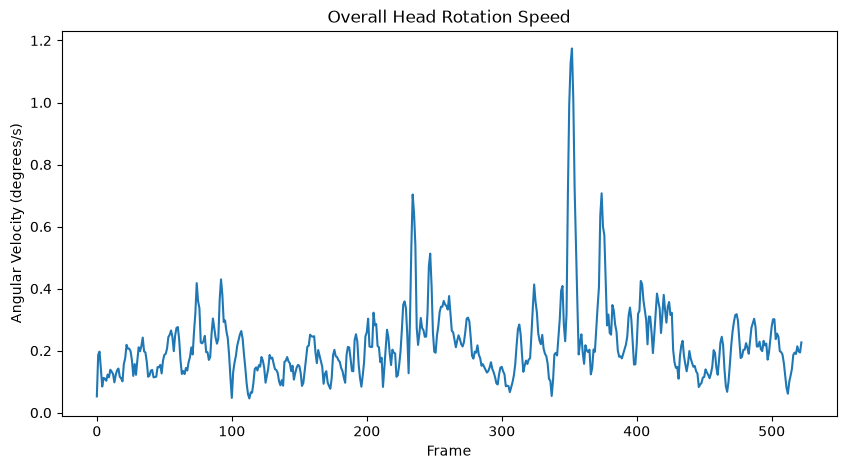

In [28]:
# plot it

plt.figure(figsize=(10, 5))
plt.plot(speed)
plt.title('Overall Head Rotation Speed')
plt.xlabel('Frame')
plt.ylabel('Angular Velocity (degrees/s)')
plt.show()

In [31]:
def calc_speed(openface_features, fps=30):
    """This function calculates the speed of pitch, roll, and yaw separately"""

    Rx_speed = openface_features['pose_Rx'].diff().fillna(0) * fps
    Ry_speed = openface_features['pose_Ry'].diff().fillna(0) * fps
    Rz_speed = openface_features['pose_Rz'].diff().fillna(0) * fps

    # smoothing
    Rx_speed = signal.savgol_filter(Rx_speed, 7, 3)
    Ry_speed = signal.savgol_filter(Ry_speed, 7, 3)
    Rz_speed = signal.savgol_filter(Rz_speed, 7, 3)
    
    return Rx_speed, Ry_speed, Rz_speed

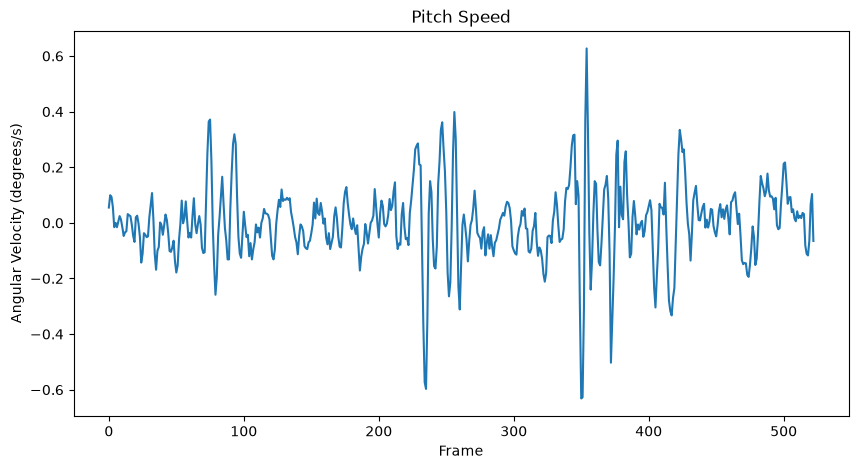

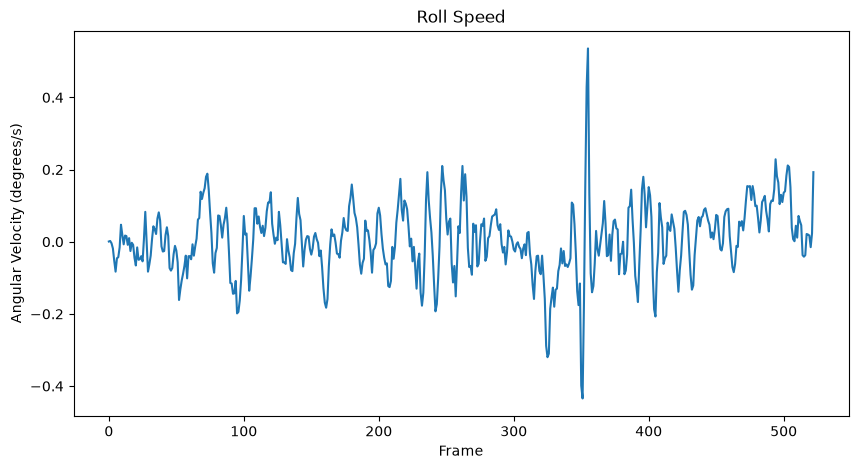

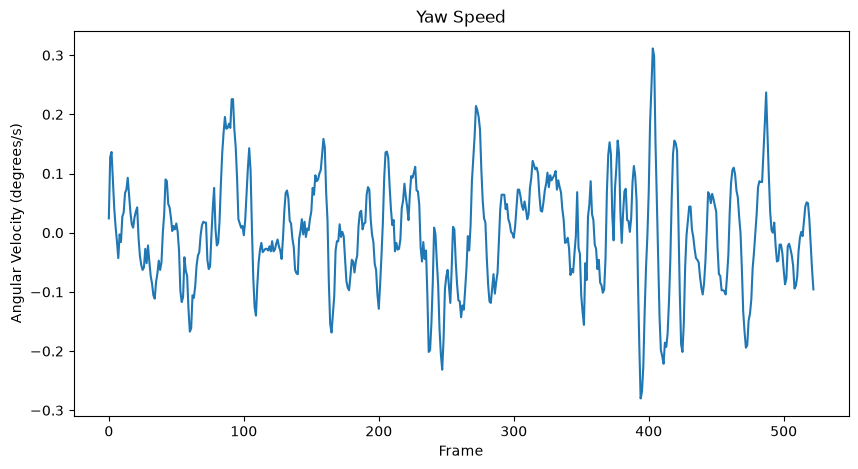

In [32]:
# get the speed
Rx_speed, Ry_speed, Rz_speed = calc_speed(openface_features)

# plot it

plt.figure(figsize=(10, 5))
plt.plot(Rx_speed)
plt.title('Pitch Speed')
plt.xlabel('Frame')
plt.ylabel('Angular Velocity (degrees/s)')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Ry_speed)
plt.title('Roll Speed')
plt.xlabel('Frame')
plt.ylabel('Angular Velocity (degrees/s)')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Rz_speed)
plt.title('Yaw Speed')
plt.xlabel('Frame')
plt.ylabel('Angular Velocity (degrees/s)')
plt.show()

Now that we have the speed we can also look at acceleration, i.e the change in velocity, which is useful to detect sudden head movements. We'll do this separately for yaw, roll, and pitch but theoretically you can also do it avaraged over the three signals for head rotation in general. Just like with speed.

In [33]:
def calc_acceleration(Rx_speed, Ry_speed, Rz_speed, fps=30):

    Rx_acc = np.diff(Rx_speed, prepend=Rx_speed[0]) * fps
    Ry_acc = np.diff(Ry_speed, prepend=Ry_speed[0]) * fps
    Rz_acc = np.diff(Rz_speed, prepend=Rz_speed[0]) * fps   

    return Rx_acc, Ry_acc, Rz_acc

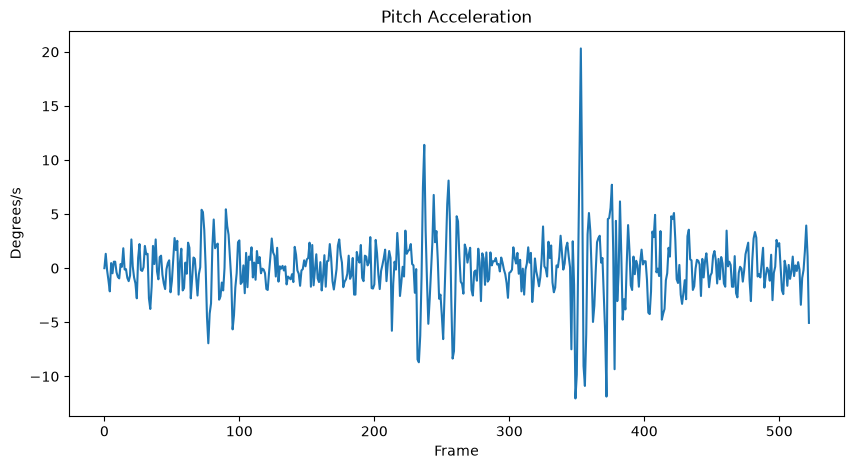

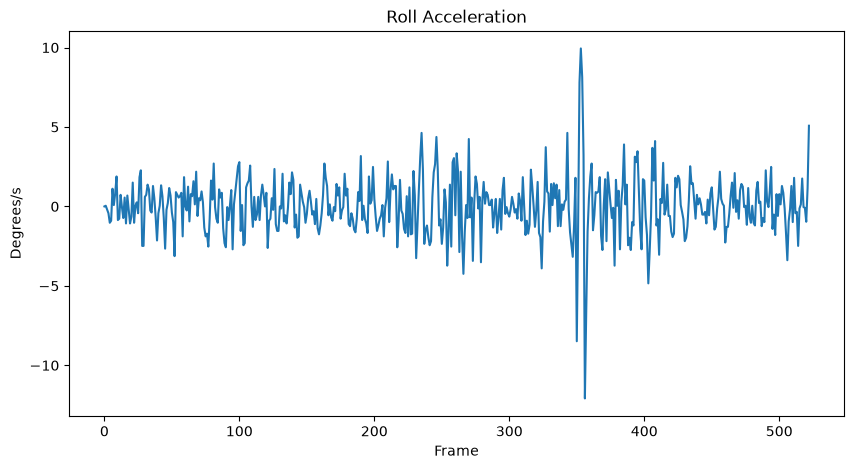

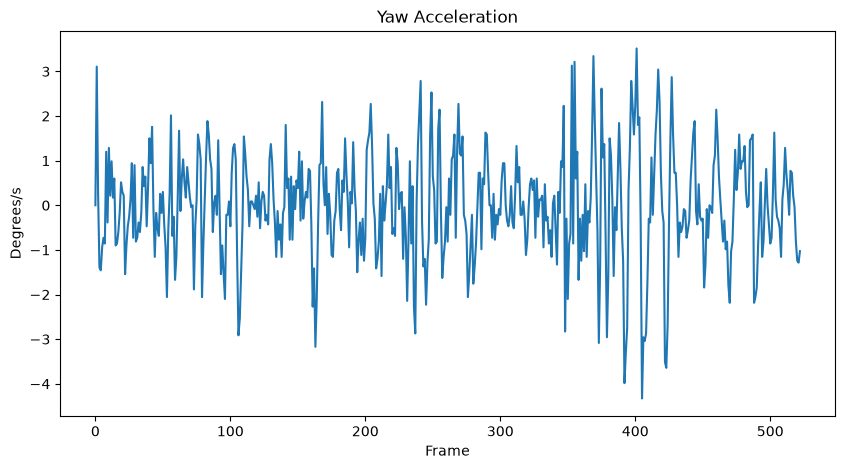

In [34]:
# get the acceleration
Rx_acc, Ry_acc, Rz_acc = calc_acceleration(Rx_speed, Ry_speed, Rz_speed)

# plot it

plt.figure(figsize=(10, 5))
plt.plot(Rx_acc)
plt.title('Pitch Acceleration')
plt.xlabel('Frame')
plt.ylabel('Degrees/s')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Ry_acc)
plt.title('Roll Acceleration')
plt.xlabel('Frame')
plt.ylabel('Degrees/s')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Rz_acc)
plt.title('Yaw Acceleration')
plt.xlabel('Frame')
plt.ylabel('Degrees/s')
plt.show()

<h3> Eye Gaze Analysis </h3>

Now let's take a look at the eye gaze. We have x,y,z coordinates for both eyes. Eye 0 is the leftmost in the video and eye 1 is the rightmost one (in the direction of the eye gaze). We further have gaze angle for the x (left-right) and y (up-down) axis.

The first thing we want to investigate is gaze direction.

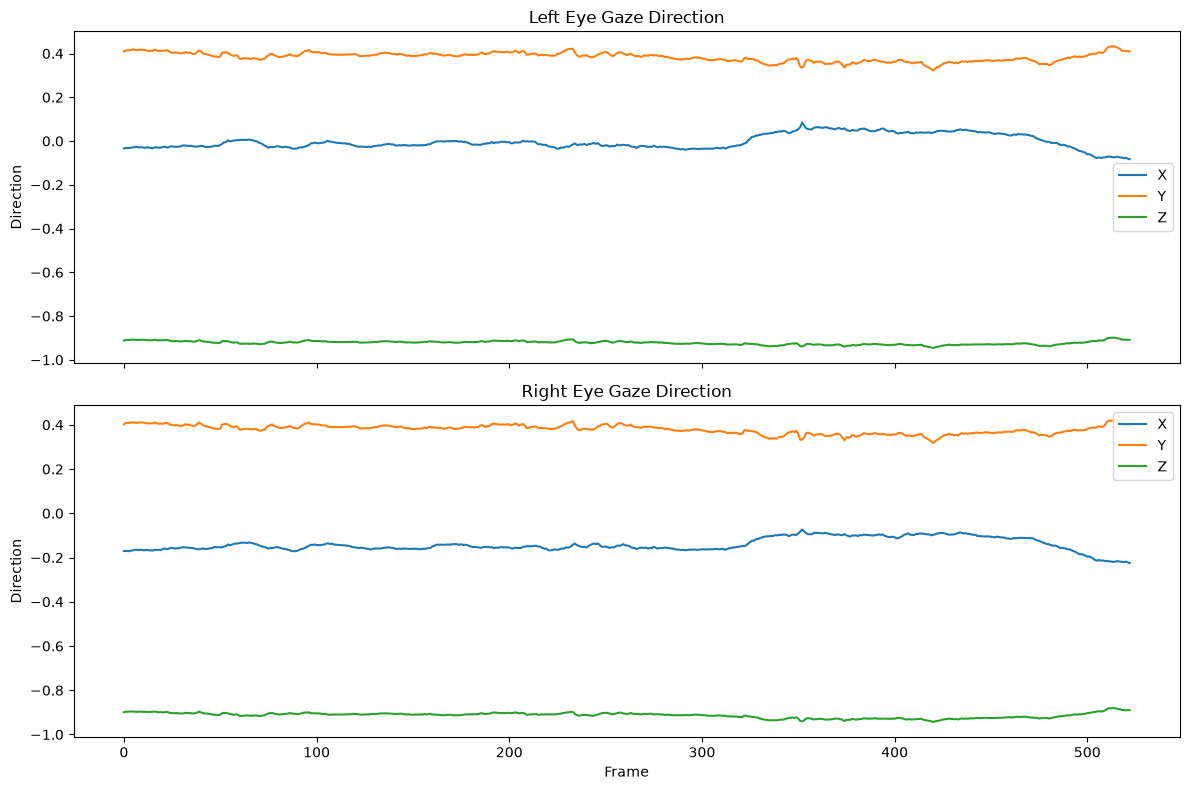

In [36]:
# let's plot gaze direction for the left and right eye

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Left eye (gaze_0)
ax[0].plot(openface_features['gaze_0_x'], label='X')
ax[0].plot(openface_features['gaze_0_y'], label='Y')
ax[0].plot(openface_features['gaze_0_z'], label='Z')
ax[0].set_title('Left Eye Gaze Direction')
ax[0].set_ylabel('Direction')
ax[0].legend()

# Right eye (gaze_1)
ax[1].plot(openface_features['gaze_1_x'], label='X')
ax[1].plot(openface_features['gaze_1_y'], label='Y')
ax[1].plot(openface_features['gaze_1_z'], label='Z')
ax[1].set_title('Right Eye Gaze Direction')
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Direction')
ax[1].legend()

plt.tight_layout()
plt.show()

You can see here that the z-axis is quite different than the other two. It measures how much the person is looking forward, i.e. how much the gaze is aligned with the camera axis. Depending on your data collection this might not be so informative. And depending on your analysis focus, you can also decide to drop z.

Generally, we can also average both eyes because the two eye vectors are probably very similar since people tend to look in the same direction with both eyes.

C:\Users\jtrujil\AppData\Local\Temp\ipykernel_27364\2742436757.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  openface_features['gaze_x'] = (
C:\Users\jtrujil\AppData\Local\Temp\ipykernel_27364\2742436757.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  openface_features['gaze_y'] = (
C:\Users\jtrujil\AppData\Local\Temp\ipykernel_27364\2742436757.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all co

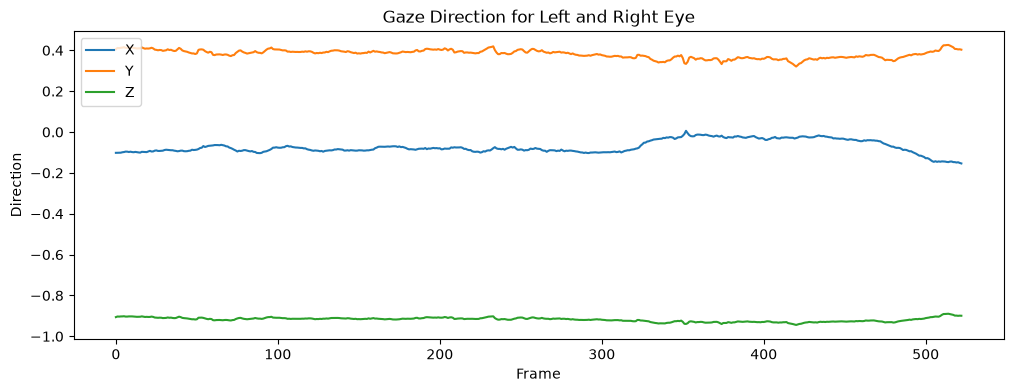

In [37]:
openface_features['gaze_x'] = (
    openface_features['gaze_0_x'] +
    openface_features['gaze_1_x']
) / 2

openface_features['gaze_y'] = (
    openface_features['gaze_0_y'] +
    openface_features['gaze_1_y']
) / 2

openface_features['gaze_z'] = (
    openface_features['gaze_0_z'] +
    openface_features['gaze_1_z']
) / 2

plt.figure(figsize=(12, 4))
plt.plot(openface_features['gaze_x'], label='X')
plt.plot(openface_features['gaze_y'], label='Y')
plt.plot(openface_features['gaze_z'], label='Z')
plt.title('Gaze Direction for Left and Right Eye')
plt.xlabel('Frame')
plt.ylabel('Direction')
plt.legend(loc='upper left')
plt.show()

Alternatively, we can use the gaze angle data to plot horizontal (x-axis) and vertical (y-axis) changes in gaze. These are described in radians (angular measures) in world coordinates.

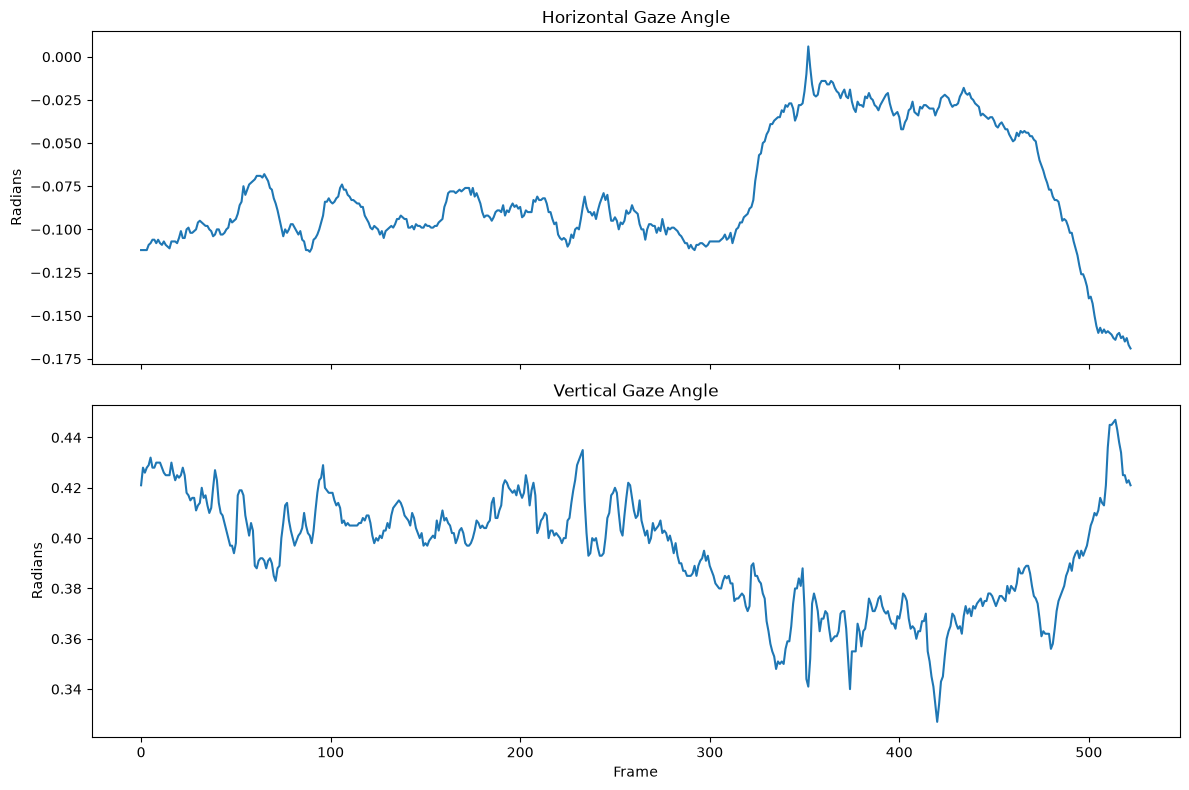

In [38]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(openface_features['gaze_angle_x'])
ax[0].set_title('Horizontal Gaze Angle')
ax[0].set_ylabel('Radians')

ax[1].plot(openface_features['gaze_angle_y'])
ax[1].set_title('Vertical Gaze Angle')
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Radians')

plt.tight_layout()
plt.show()

Have a look at the difference between the averaged gaze direction plot and the gaze angle plot. Essentially the two describe the same pattern, i.e. the gaze direction, but in different dimensions. 

Something else we can do is create a heat map from the gaze angle data.

In [39]:
# define variables
x = openface_features['gaze_angle_x']
y = openface_features['gaze_angle_y']

# normalize to 0 to 1 range
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

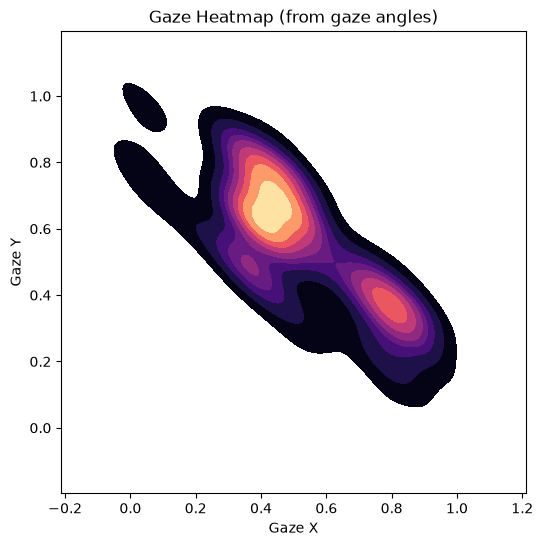

In [40]:
# create heatmap
import seaborn as sns

plt.figure(figsize=(6, 6))

sns.kdeplot(
    x=x_norm,
    y=y_norm,
    fill=True,
    cmap="magma",
    thresh=0.05
)

plt.title("Gaze Heatmap (from gaze angles)")
plt.xlabel("Gaze X")
plt.ylabel("Gaze Y")
plt.show()

This is of course only useful and informative if you overlay it with what the participant saw. That can be a scene or a stimulus video or image. Only then can you draw information from the points where the ezes were mostly located.

<h3>Gaze Velocity, Fixations, and Saccades</h3>

Using the gaze angle data, we can investigate gaze behaviour further, looking at gaze switches, that is the change in gaze direction between fixations (stable gaze) and saccades (fast movement between fixations). 

The formula for velocity is v = delta s / delta t, where delta s is the angular distance (in radians or degrees) and delat t the time between samples.

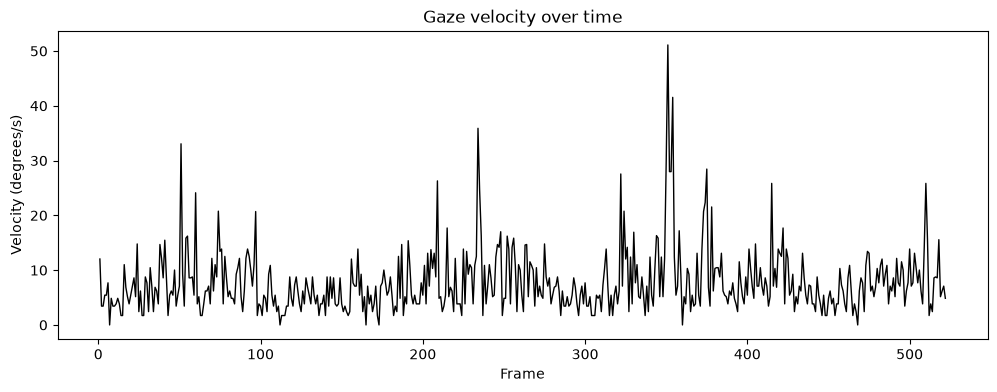

In [42]:
# first we want to calculate the gaze velocity and plot the distribution
fps = 30

gaze_velocity = np.sqrt(
    openface_features['gaze_angle_x'].diff()**2 +
    openface_features['gaze_angle_y'].diff()**2
) * fps

# convert from radians to degrees
gaze_velocity_deg = np.degrees(gaze_velocity)

# plot velocity over time
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(gaze_velocity_deg, color='black', linewidth=1)

# Example threshold
ax.set_title('Gaze velocity over time')
ax.set_xlabel('Frame')
ax.set_ylabel('Velocity (degrees/s)')

plt.show()

Gaze velocity can give us information about fixations and saccades but we first need to define a threshold for the two. From the literature we know that velocity is low for fixation (< 100 degrees/s) and high for saccades (> 300 degrees/s)(https://www.sciencedirect.com/topics/engineering/saccades-and-fixation). But because of the low resolution of OpenFace compared to Eye Trackers, we might need to adjust those values a bit in order to detect gaze movement. Looking at the plot, we can try to determine a good threshold for our saccades. To me, 25 seems reasonable, so I will define this as threshold but you are welcome to think along and try out other values.

In [43]:
# define saccades and fixations
threshold = 25
is_saccade = gaze_velocity_deg > threshold
is_fixation = gaze_velocity_deg < threshold


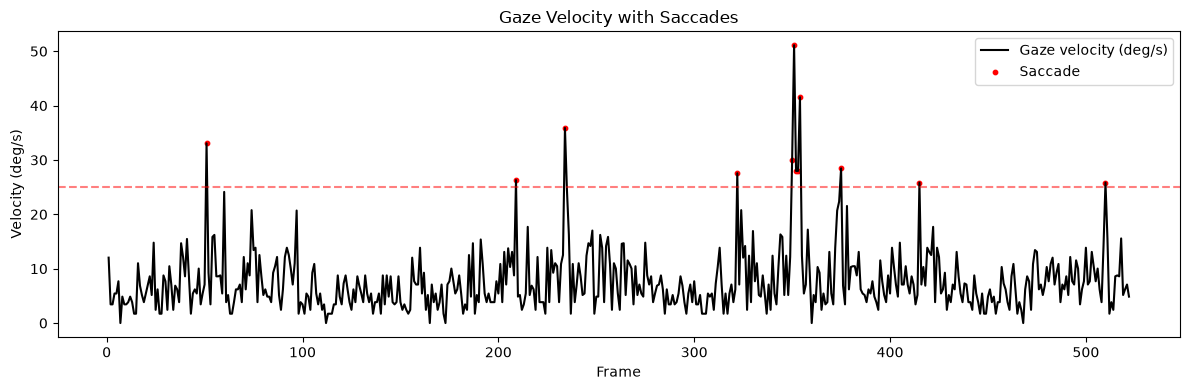

In [44]:
# plot gaze speed over time and highlight switches

plt.figure(figsize=(12, 4))

plt.plot(gaze_velocity_deg, label="Gaze velocity (deg/s)", color="black")

plt.scatter(
    np.where(is_saccade)[0],
    gaze_velocity_deg[is_saccade],
    color="red",
    s=10,
    label="Saccade"
)
plt.axhline(threshold, color="red", linestyle="--", alpha=0.5)

plt.title("Gaze Velocity with Saccades")
plt.xlabel("Frame")
plt.ylabel("Velocity (deg/s)")
plt.legend()

plt.tight_layout()
plt.show()

So far, it seems like nobody has been doing eye tracking-like measurements using OpenFace gaze data, usually because regular eye tracking is much more reliable and accurate. This last attempt has therefore to be taken with a grain of salt and should be further delevoped.

<h3>Gaze Velocity and Switches</h3>

In this tutorial, we showed you just some of the data visualizations and analyses that you can do with OpenFace.  We were now looking at data from one participant, but you might want to average the movement behavior of all your participants in order to do group comparisons or look at different conditions of your experiment. Generally, the use of OpenFace and code to analyse the data depends strongly on your research question and dataset, and on what you want to explore and how you go about it.